# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Umm e Khadija Kamanger)_

**Roll Number:** _(023-24-0071)_

**GitHub Repository:** _(https://github.com/kamangerkhadija5-collab/ML_LAB.git)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_(The company is losing customers and wants to understand which customers are likely to leave)_       
_(The obvious candidate is: Churn... because the dataset describes Churn as the target with Yes/No values)_
_(business problem: Losing the costumer)_
_(what the company wants: Company want to understand which costumers are likely to leave)_
_(what you think the target is: The goal is to understand the raw data.)_

**Answer 2:**
_(1. tenure: customers with shorter tenure may be more likely to leave Contract  2.Customers on shorter-term contracts may have a higher tendency to leave. 3. MonthlyCharges: Higher monthly charges may be associated with a greater likelihood of churn. 4. InternetService: The type of internet service may influence customer satisfaction and churn. 5. PaymentMethod: Different payment methods may be associated with different customer churn patterns.)_

**Answer 3:**
_(Do customers with month-to-month contracts churn more? Does higher monthly spending relate to higher churn?)_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [2]:
# Task 4 — dataset shape, column names, data types
print("Shaped Data: ", df.shape)
print("\nNumerical Dataset: ", df.select_dtypes(include=[np.number]).columns.tolist())
print("\nCategorical Dataset: ", df.select_dtypes(include=['object', 'string']).columns.tolist())


Shaped Data:  (7043, 21)

Numerical Dataset:  ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Dataset:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [3]:
# Task 5 — identify identifier columns / wrong data types
print(df.dtypes)
print("\nSample Data: ")
display(df.head(5))

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Sample Data: 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Task 6 — unique values in 3 categorical columns
for col in ['Contract', 'InternetService' , 'PaymentMethod']:
    print(f" --- Unique values in {col} --- ")
    print(df[col].unique())
    print()

 --- Unique values in Contract --- 
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

 --- Unique values in InternetService --- 
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 --- Unique values in PaymentMethod --- 
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_
_(In this task i lean how to visualize the data set , hoe the data is stored in seaborn, and how to see the numerical and categorical data)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({'Missing Count':missing_count, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Percentage (%)
TotalCharges             11            0.16


In [6]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print(f"Full duplicate rows count: {duplicate_rows}")
print(f"Duplicate customerID count: {duplicate_ids}")


Full duplicate rows count: 0
Duplicate customerID count: 0


In [7]:
# Task 9 — investigate a suspicious / invalid value
blank_total_charges = df[df['TotalCharges'].astype(str).str.strip() == ""]
print(f"Numbers of rows with blank in TotalCharges: {len(blank_total_charges)}")
display(blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Numbers of rows with blank in TotalCharges: 0


,customerID,tenure,MonthlyCharges,TotalCharges


**Answer 7 (which missing-value problems need action, and why):**
_(TotalCharges has 11 missing values. They need action because ML models cannot run on missing numeric data.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(They are different issues: duplicate rows copy entire records, while duplicate IDs copy only unique customer labels.)_

**Answer 9 (suspicious value found and how):**
_(Found empty spaces (" ") in TotalCharges by checking why its data type was text instead of float.)_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text (object) instead of numeric | Convert to numeric | `pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')` | The column represents a dollar amount and must be numeric for any statistics, plotting, or modeling; `errors='coerce'` turns unparseable blank strings into `NaN` instead of crashing. |
| 11 rows with missing `TotalCharges` (all have `tenure == 0`) | Impute with 0 | `df['TotalCharges'].fillna(0)` | These are brand-new customers who haven't been billed yet (tenure = 0), so `TotalCharges` is legitimately zero rather than truly "missing" — imputing 0 is more faithful than dropping the rows or using the mean. |
| `customerID` is a unique identifier | Keep for now, drop before modeling | Flag as non-predictive in ML-readiness table | It has no predictive value (one unique value per row) but is useful for joins/auditing, so it is not deleted during cleaning — only excluded from model features. |
| `SeniorCitizen` encoded as 0/1 integer but is conceptually categorical | Leave as-is / note in readiness table | No transformation needed for EDA | It is already numeric-encoded, which is fine for now; only relabeling for readability (0→No, 1→Yes) would help interpretability but isn't required for correctness. |
| Full duplicate rows / duplicate `customerID`s | No action needed | `df.duplicated().sum()` and `df['customerID'].duplicated().sum()` both returned 0 | The dataset has no duplicate rows or duplicate customer IDs, so there is nothing to remove. |

In [8]:
# Task 11 — apply cleaning decisions
df_clean = df.copy()

# 1. Fix TotalCharges data type (text -> numeric)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].astype(str).str.strip(), errors='coerce')

# 2. Handle missing TotalCharges values
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 3. Strip whitespace from text columns (warning fixed here!)
obj_cols = df_clean.select_dtypes(include=['object', 'string']).columns
for c in obj_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()

# 4. Drop exact duplicate rows
df_clean = df_clean.drop_duplicates()



In [9]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values per column after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("(empty output above means: no missing values remain)\n")

print("TotalCharges dtype after cleaning:", df_clean['TotalCharges'].dtype)

print("\nFull duplicate rows:", df_clean.duplicated().sum())
print("Duplicate customerIDs:", df_clean['customerID'].duplicated().sum())

print("\nShape before vs after cleaning:", df.shape, "->", df_clean.shape)

Missing values per column after cleaning:
Series([], dtype: int64)
(empty output above means: no missing values remain)

TotalCharges dtype after cleaning: float64

Full duplicate rows: 0
Duplicate customerIDs: 0

Shape before vs after cleaning: (7043, 21) -> (7043, 21)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

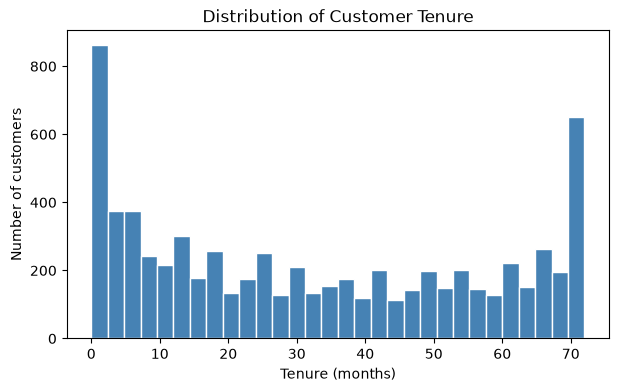

In [10]:
# Task 12 — numerical feature 1: distribution plot

plt.figure(figsize=(7,4))
plt.hist(df_clean['tenure'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.title('Distribution of Customer Tenure')
plt.show()



**Observation:** _(tenure has two big peaks: one for new customers (0–2 months) and one for long-term users (around 72 months). People either leave right away or stay for years.)_

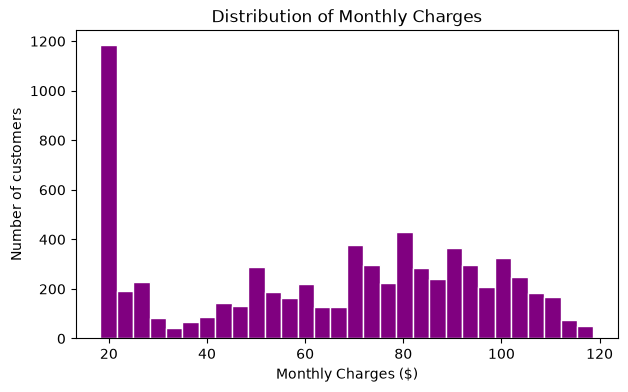

In [11]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(7,4))
plt.hist(df_clean['MonthlyCharges'], bins=30, color='purple', edgecolor='white')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.title('Distribution of Monthly Charges')
plt.show()


**Observation:** _(MonthlyCharges go from $18 to $120. Most people pay around $20 (basic phone) or between $70–$100 (internet and extra features).)_

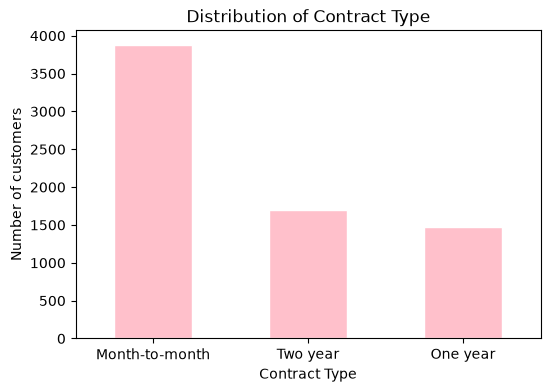

In [12]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(6,4))
df_clean['Contract'].value_counts().plot(kind='bar', color='pink', edgecolor='white')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.title('Distribution of Contract Type')
plt.xticks(rotation=0)
plt.show()


**Observation:** _(About 55% of users are on Month-to-month plans. They can cancel anytime with no penalty, so they are the most likely to leave.)_

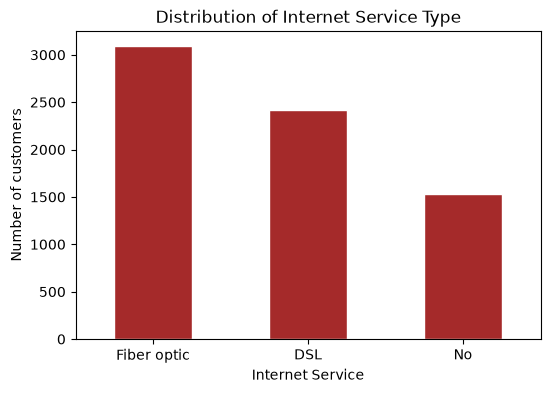

In [13]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(6,4))
df_clean['InternetService'].value_counts().plot(kind='bar', color='brown', edgecolor='white')
plt.xlabel('Internet Service')
plt.ylabel('Number of customers')
plt.title('Distribution of Internet Service Type')
plt.xticks(rotation=0)
plt.show()


**Observation:** _(Fiber optic is the most popular internet option (44%), followed by DSL (34%). Fiber is more expensive, which might explain why those customers churn more.)_

**Answer 13 (outliers / skew and possible explanation):**
_(TotalCharges is skewed to the right because bills add up over time—long-term customers naturally pay thousands, while new customers have paid very little. This is normal behavior, not data entry errors. tenure and MonthlyCharges aren't very skewed and don't have extreme outliers, as their numbers simply reflect different plan types and customer groups.)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [14]:
# Task 14 — churn counts and percentages
churn_counts = df_clean['Churn'].value_counts()
churn_pct = (df_clean['Churn'].value_counts(normalize=True) * 100).round(2)

churn_summary = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct})
print(churn_summary)

       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


**Answer 14 (balanced or imbalanced?):**
_(The target is imbalanced. About 73.5% of customers stayed ("No"), while only 26.5% churned ("Yes"). This is roughly a 3:1 ratio, so "No" dominates the dataset.)_

**Answer 15 (why imbalance might matter later):**
_(A model can get 73% accuracy just by blindly guessing "No" for everyone, which makes accuracy a misleading metric. Because the model sees fewer "Yes" examples, it might struggle to catch real churners. Later on, we will need metrics like precision, recall, or F1-score to judge performance properly.)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


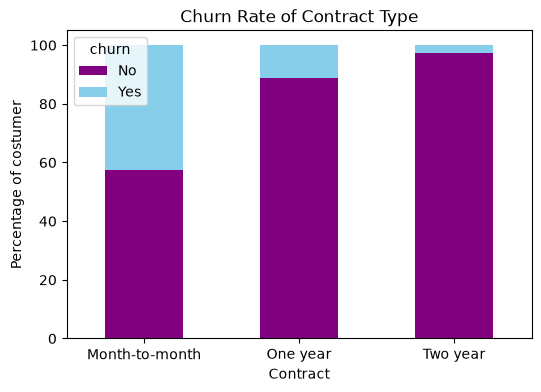

In [15]:
# Task 16 — categorical feature 1 vs Churn
ct_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(ct_contract.round(2))

ct_contract.plot(kind='bar', stacked=True, figsize=(6,4), color=['purple', 'skyblue'])
plt.ylabel('Percentage of costumer')
plt.title('Churn Rate of Contract Type')
plt.xticks(rotation=0)
plt.legend(title='churn')
plt.show()

**Observation:** _Churn rate drops sharply as contract length increases._
**Evidence:** _Month-to-month customers churn at ~42.7%, One year contract customers at ~11.3%, and Two year contract customers at only ~2.8%_
**Possible Explanation:** _Longer contracts likely come with lock-in effects (cancellation fees, promotional pricing tied to the term) and also tend to attract more committed, satisfied customers in the first place, so both the structural friction to leave and the underlying customer intent point the same way._

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


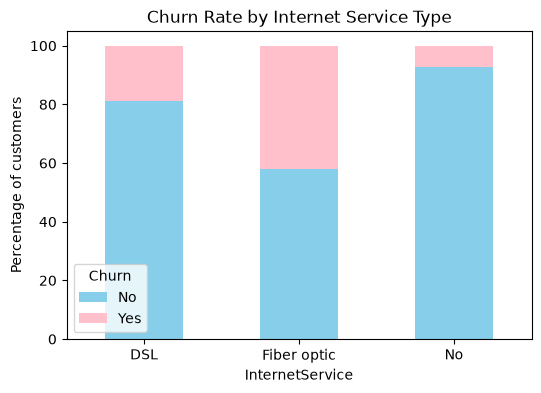

In [16]:
# Task 16 — categorical feature 2 vs Churn
ct_internet = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
print(ct_internet.round(2))

ct_internet.plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue','pink'])
plt.ylabel('Percentage of customers')
plt.title('Churn Rate by Internet Service Type')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


**Observation:** _Fiber optic customers churn far more often than DSL or no-internet customers._
**Evidence:** _Fiber optic churn rate is ~41.9%, versus ~19.0% for DSL and only ~7.4% for customers with no internet service._
**Possible Explanation:** _Fiber optic is the most expensive internet tier (seen in Part 5), so higher price combined with possibly more competition/alternatives for fast internet could make these customers more price-sensitive and quicker to switch providers if unhappy with cost or service quality_

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


C:\Users\user\AppData\Local\Temp\ipykernel_15068\2100328539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=['seagreen','indianred'])


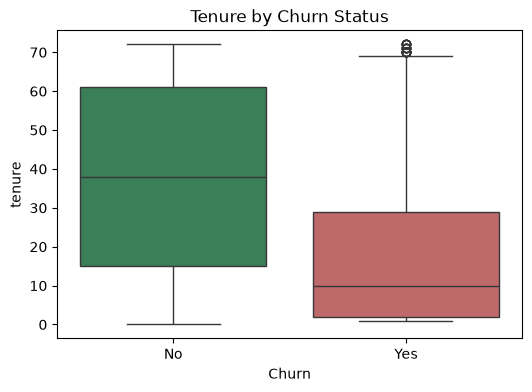

In [17]:
# Task 17 — numerical feature 1 vs Churn
print(df_clean.groupby('Churn')['tenure'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=['seagreen','indianred'])
plt.title('Tenure by Churn Status')
plt.show()


**Observation:** _Customers who churn have much shorter tenure than those who stay._
**Evidence:** _Average tenure for churned customers is ~18.0 months, compared to ~37.6 months for retained customers — roughly half as long — and the boxplot shows the churned group's median and interquartile range sitting well below the retained group's_
**Possible Explanation:** _This fits an "early risk" pattern common in subscription businesses: new customers haven't yet built loyalty, habits, or sunk-cost investment in the service, so they are more likely to leave early if their initial experience doesn't meet expectations._

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


C:\Users\user\AppData\Local\Temp\ipykernel_15068\2296902077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['seagreen','indianred'])


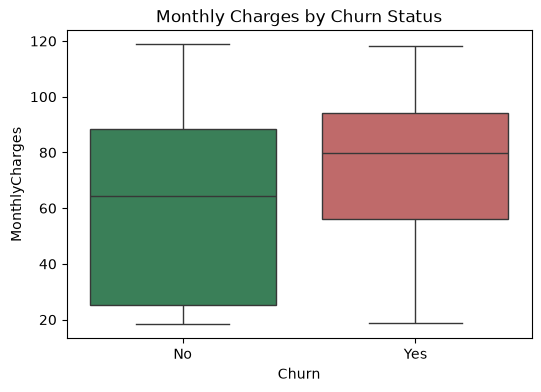

In [18]:
# Task 17 — numerical feature 2 vs Churn
print(df_clean.groupby('Churn')['MonthlyCharges'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['seagreen','indianred'])
plt.title('Monthly Charges by Churn Status')
plt.show()


**Observation:** _Customers who churn tend to pay higher monthly charges_
**Evidence:** _Average `MonthlyCharges` for churned customers is ~\$74.44, compared to ~\$61.27 for retained customers, and the boxplot shows the churned group shifted noticeably higher._
**Possible Explanation:** _This is consistent with the Contract and InternetService findings above — customers paying more (often fiber optic, month-to-month) may feel they are not getting proportional value, making them more price-sensitive and more willing to switch providers_

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


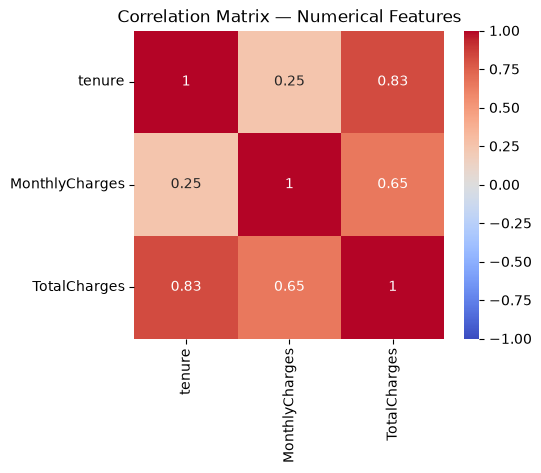

In [19]:
# Task 18 — correlation matrix and heatmap
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_clean[num_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features')
plt.show()


**Answer 18 (most correlated pairs):**
_(`tenure` and `TotalCharges` are the most strongly correlated pair (r ≈ 0.83), followed by `MonthlyCharges` and `TotalCharges` (r ≈ 0.65). `tenure` and `MonthlyCharges` are only weakly correlated (r ≈ 0.25) )_

**Answer 19 (correlation vs. causation; potential problems):**
_(Correlation here does not imply causation — `TotalCharges` is correlated with `tenure` largely by mathematical construction, since total charges accumulate as tenure increases (roughly `TotalCharges ≈ tenure × MonthlyCharges`), not because one independently causes the other. This kind of near-redundancy could be a problem for a future model: including both `tenure` and `TotalCharges` adds little new information beyond what `tenure` and `MonthlyCharges` already provide, and highly correlated features can make coefficients unstable in linear models (multicollinearity) or simply add noise without predictive benefit in tree-based models.)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(`customerID` is a pure identifier — it is unique per row and carries no real-world predictive signal, so it should never be used as a model feature (it would only let the model "memorize" training rows). No other column in this dataset looks like classic post-outcome leakage (e.g. there is no "cancellation date" or "reason for leaving" column) — every remaining feature (contract type, services subscribed, charges, demographics) describes something that is genuinely knowable about a customer while they are still an active customer, before any churn decision is observed. `TotalCharges` is worth flagging as borderline: it is legitimate (known at prediction time, since it is billing-to-date), but because it is almost fully determined by `tenure × MonthlyCharges`, it doesn't add much true predictive information beyond those two columns.)_

**Answer 21 (what would go wrong):**
_(If an identifier like `customerID` were fed into the model as a feature, the model could effectively memorize which specific IDs churned in training data, giving inflated training performance that collapses on new customers with unseen IDs. More generally, if any column that is only known after the fact (e.g., something recorded as a consequence of churn) were included, the model would appear highly accurate during evaluation but would fail in real deployment, because that information simply won't exist yet when a prediction is actually needed)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value; only useful for row-level bookkeeping. |
| gender | Categorical | Feature | Keep | Clean binary category (Male/Female), potentially useful, will need encoding in Lab 3. |
| SeniorCitizen | Numerical (binary-encoded) | Feature | Keep | Already 0/1, ready to use; senior citizens showed a higher churn rate (~41.7% vs ~23.6%). |
| Partner | Categorical | Feature | Keep | Clean Yes/No category, plausible link to household stability and churn. |
| tenure | Numerical | Feature | Keep | Strong relationship with churn (shorter tenure -> more churn); needs no cleaning. |
| PhoneService | Categorical | Feature | Keep | Clean Yes/No category describing subscribed services. |
| MultipleLines | Categorical | Feature | Keep | Clean category describing subscribed services. |
| InternetService | Categorical | Feature | Keep | Strong relationship with churn (Fiber optic churns most); clean categories. |
| OnlineSecurity | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| OnlineBackup | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| DeviceProtection | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| TechSupport | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| StreamingTV | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| StreamingMovies | Categorical | Feature | Keep | Add-on service, plausible link to churn/satisfaction. |
| Contract | Categorical | Feature | Keep | Strongest categorical relationship with churn found in Part 7. |
| PaperlessBilling | Categorical | Feature | Keep | Clean Yes/No category, plausible billing-behavior signal. |
| PaymentMethod | Categorical | Feature | Keep | Clean 4-category column, plausible billing-behavior signal. |
| MonthlyCharges | Numerical | Feature | Keep | Clean numeric column; higher charges linked to higher churn. |
| TotalCharges | Numerical | Feature (use with care) | Clean, then keep with caution | Had to be converted from text to numeric and 11 missing values (tenure = 0 customers) imputed with 0; highly correlated with tenure so may add redundancy. |
| Churn | Categorical | Target | Keep | This is the label Lab 3 will predict; imbalanced (~73.5% No / ~26.5% Yes). |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [20]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Fix TotalCharges data type
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'].astype(str).str.strip(), errors='coerce')

# Impute the 11 missing TotalCharges values (all tenure == 0, brand-new customers)
clean_df.loc[clean_df['tenure'] == 0, 'TotalCharges'] = clean_df.loc[clean_df['tenure'] == 0, 'TotalCharges'].fillna(0)
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(clean_df['TotalCharges'].median())

# Strip whitespace from all text columns
obj_cols = clean_df.select_dtypes(include=['object', 'string']).columns
for c in obj_cols:
    clean_df[c] = clean_df[c].astype(str).str.strip()

# Drop exact duplicate rows, if any
clean_df = clean_df.drop_duplicates()

# Remove the pure identifier column before it can accidentally be used as a feature
clean_df = clean_df.drop(columns=['customerID'])

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_churn.csv with shape:", clean_df.shape)

Saved clean_churn.csv with shape: (7043, 20)


In [21]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print(clean_df.info())
print("\nMissing values per column:\n", clean_df.isnull().sum())
print("\nDuplicate rows:", clean_df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _Contract type is the single strongest driver of churn found in this analysis._
- Evidence: _Churn rate is ~42.7% for month-to-month contracts vs. ~11.3% for one-year and only ~2.8% for two-year contracts._
- Interpretation: _Contract length acts almost like a lock-in mechanism; customers without a term commitment churn at more than 10x the rate of those on two-year contracts._

**Finding 2**
- Observation: _New customers are far more likely to churn than long-tenured customers._
- Evidence: _Average tenure is ~18.0 months for churned customers vs. ~37.6 months for retained customers._
- Interpretation: _The first months of the customer relationship appear to be the highest-risk period, suggesting onboarding experience matters a great deal for retention._

**Finding 3**
- Observation: _Fiber optic internet customers churn much more than DSL or no-internet customers._
- Evidence: _Fiber optic churn rate is ~41.9%, versus ~19.0% for DSL and ~7.4% for no internet service._
- Interpretation: _Since fiber optic is also the priciest service tier, cost combined with possibly stronger competitor alternatives for fast internet may be driving this group's higher churn._

**Finding 4**
- Observation: _Churned customers pay noticeably higher monthly charges on average._
- Evidence: _Mean `MonthlyCharges` is ~\$74.44 for churned customers vs. ~\$61.27 for retained customers._
- Interpretation: _Price sensitivity appears linked to churn — customers paying more may feel they aren't getting proportional value, especially when combined with a flexible (month-to-month) contract._

**Finding 5**
- Observation: _The target variable is moderately imbalanced._
- Evidence: _73.5% of customers ("No") did not churn versus 26.5% ("Yes") who did._
- Interpretation: _Any model trained in Lab 3 will need evaluation metrics beyond plain accuracy (e.g. precision/recall/F1 for the churn class) to be meaningful._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _`TotalCharges` being stored as text instead of a numeric type, with 11 blank values hiding inside it — this would have silently broken any numeric computation or model training step until it was investigated and fixed._
2. What was the most interesting pattern you discovered?
   _How strongly contract type predicts churn on its own — a customer's churn risk changes by more than 10x just based on whether they're on a month-to-month vs. two-year contract._
3. Which feature seems most useful for predicting churn?
   _`Contract`, based on how cleanly it separates churn rates across its three categories, closely followed by `tenure`._
4. Which feature should probably not be used, and why?
   _`customerID`, since it is a unique identifier with no generalizable predictive signal and would only encourage the model to memorize training rows instead of learning patterns._
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _Categorical columns will need to be encoded (e.g. one-hot or ordinal encoding) since models require numeric input; numerical features like `tenure`, `MonthlyCharges`, and `TotalCharges` will likely need scaling/normalization; the target `Churn` will need to be encoded as 0/1; and because the target is imbalanced, the train/test split should be stratified and imbalance-aware evaluation metrics (or resampling) should be planned for._
6. What would you do next if you had another 3 hours?
   _I would engineer a few new features (e.g. average monthly spend = TotalCharges/tenure, or a count of subscribed add-on services), dig deeper into interaction effects (e.g. Contract x InternetService together), and check whether senior citizens or customers without partners/dependents show compounding churn risk when combined with contract type._


---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

Churn rate (%) by Contract x InternetService:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


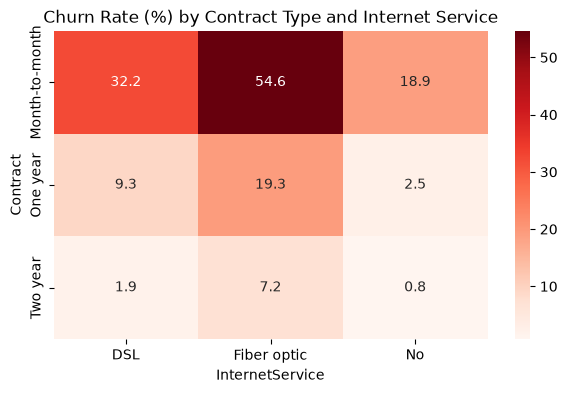


Churn rate for senior citizens without a partner: 48.9%
Overall churn rate: 26.5%

Average churn rate by number of add-on services subscribed:
NumAddonServices
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Churn, dtype: float64


In [22]:
# Bonus — optional exploration
# 1. Additional visualization: churn rate across a combination of two segments
#    (Contract type x Internet Service)
combo = (df_clean.groupby(['Contract', 'InternetService'])['Churn']
         .apply(lambda s: (s == 'Yes').mean() * 100)
         .unstack())
print("Churn rate (%) by Contract x InternetService:")
print(combo.round(1))

plt.figure(figsize=(7,4))
sns.heatmap(combo, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) by Contract Type and Internet Service')
plt.show()

# 2. Surprising subgroup: Senior citizens without a partner
subgroup = df_clean[(df_clean['SeniorCitizen'] == 1) & (df_clean['Partner'] == 'No')]
churn_rate_subgroup = (subgroup['Churn'] == 'Yes').mean() * 100
print(f"\nChurn rate for senior citizens without a partner: {churn_rate_subgroup:.1f}%")
print(f"Overall churn rate: {(df_clean['Churn']=='Yes').mean()*100:.1f}%")

# 3. Feature-engineering opportunity: services count
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df_clean['NumAddonServices'] = (df_clean[service_cols] == 'Yes').sum(axis=1)
print("\nAverage churn rate by number of add-on services subscribed:")
print(df_clean.groupby('NumAddonServices')['Churn'].apply(lambda s: (s=='Yes').mean()*100).round(1))


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook